### Imports

In [1]:
import random
import datetime

import numpy as np

import qutip as qt

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mpl_colors

from IPython.display import HTML
from matplotlib import animation

%load_ext autoreload
%autoreload 2

from utils import *

plt.rcParams["font.family"] = "serif"  # 'sans-serif', 'monospace', etc.
plt.rcParams["font.serif"] = ["Times New Roman"]  # Specific serif font
plt.rcParams["font.size"] = 14  # Global font size
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{braket}'

### Generate Operators

In [2]:
N = 60

a = qt.destroy(N)

H_res = a.dag() * a
H_kerr = (a.dag() * a)**2
H_microwave = a.dag() + a
H_tpd = a.dag()**2 + a**2

### Plot Energy Levels

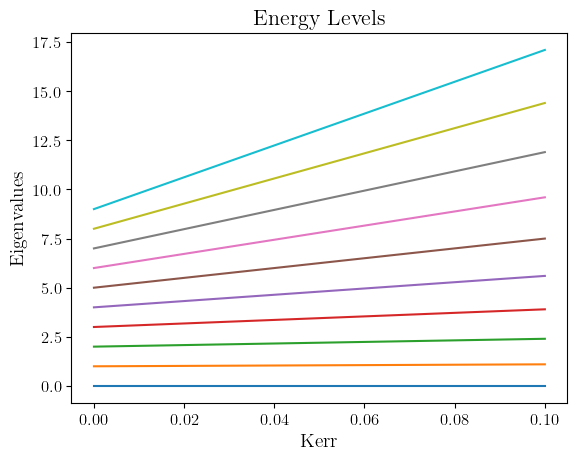

In [3]:
kerr = np.linspace(0, 0.1, 10)
tpd_amplitude = 1
num_eigenvals = 10

all_energies = []

G = 0.1

for k in kerr:
    H = H_res + k * H_kerr
    energies = np.sort(np.real(H.eigenenergies()))
    all_energies.append(energies[:num_eigenvals])

all_energies = np.array(all_energies)

for n in range(all_energies.shape[1]):
    plt.plot(kerr, all_energies[:, n])

plt.xlabel("Kerr")
plt.ylabel("Eigenvalues")
plt.title("Energy Levels")
plt.show()

### Plot Energy Level Spacing

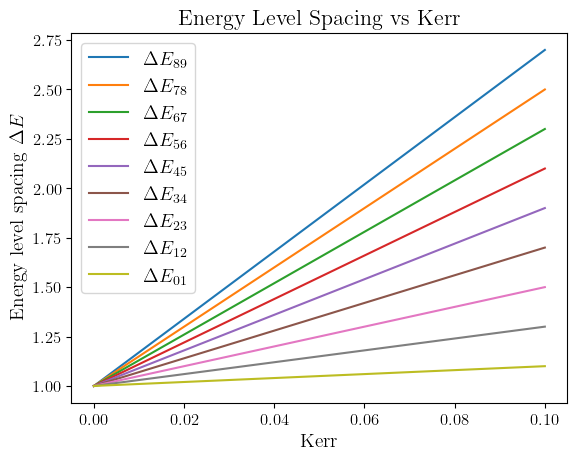

In [4]:
kerr = np.linspace(0, 0.1, 100)
all_energies = []

# Compute first 10 eigenvalues
for k in kerr:
    H = H_res + k * H_kerr
    energies = np.real(H.eigenenergies(eigvals=10))
    all_energies.append(energies)

all_energies = np.array(all_energies)

# Compute spacing between consecutive energies
level_spacings = np.diff(all_energies, axis=1)

# Plot level spacings
for n in reversed(range(level_spacings.shape[1])):
    plt.plot(kerr, level_spacings[:, n], label=rf"$\Delta E_{{{n}{n+1}}}$")

plt.xlabel("Kerr")
plt.ylabel(r"Energy level spacing $\Delta E$")
plt.title("Energy Level Spacing vs Kerr")
plt.legend()
plt.show()